<a href="https://colab.research.google.com/github/itsSolG/sales-analysis-and-forecasting/blob/main/notebooks/01_eda_sales_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Sales Data Analysis - Global Superstore**

In [17]:
#!git clone https://github.com/itsSolG/sales-analysis-and-forecasting.git

## Objective

The goal of this project is to analyze sales data to identify trends, top-performing categories, and key business insights.

Note: The dataset used in this project is a cleaned version of the Global Superstore dataset, prepared for analysis.

##Importing Libraries

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

## Data Loading

In [3]:
df = pd.read_csv("data/superstore.csv")
df.head()

,Category,City,Country,Customer.ID,Customer.Name,Discount,Market,记录数,Order.Date,Order.ID,...,Sales,Segment,Ship.Date,Ship.Mode,Shipping.Cost,State,Sub.Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,2011-01-07 00:00:00.000,CA-2011-130813,...,19,Consumer,2011-01-09 00:00:00.000,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,2011-01-21 00:00:00.000,CA-2011-148614,...,19,Consumer,2011-01-26 00:00:00.000,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,21,Consumer,2011-08-09 00:00:00.000,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,2011-08-05 00:00:00.000,CA-2011-118962,...,111,Consumer,2011-08-09 00:00:00.000,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,2011-09-29 00:00:00.000,CA-2011-146969,...,6,Consumer,2011-10-03 00:00:00.000,Standard Class,1.32,California,Paper,2011,North America,40


## Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  object 
 1   City            51290 non-null  object 
 2   Country         51290 non-null  object 
 3   Customer.ID     51290 non-null  object 
 4   Customer.Name   51290 non-null  object 
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  object 
 7   记录数             51290 non-null  int64  
 8   Order.Date      51290 non-null  object 
 9   Order.ID        51290 non-null  object 
 10  Order.Priority  51290 non-null  object 
 11  Product.ID      51290 non-null  object 
 12  Product.Name    51290 non-null  object 
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  object 
 16  Row.ID          51290 non-null  int64  
 17  Sales           51290 non-null 

In [5]:
df.describe()

,Discount,记录数,Profit,Quantity,Row.ID,Sales,Shipping.Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


## Total Revenue and Profit

In [6]:
total_sales = df["Sales"].sum()
total_prift = df["Profit"].sum()

print("Total sales:", total_sales)
print("Total profit:", total_prift)

Total sales: 12642905
Total profit: 1467457.2912800002


### Insight

The total sales amount to over 12.6 million, while total profit is approximately 1.46 million.

This shows that although the business generates high revenue, the profit margin is relatively low, indicating that costs may be significantly impacting overall profitability.

In [7]:
profit_margin = (df["Profit"].sum()/df["Sales"].sum())*100
print("Profit Margin:", profit_margin)

Profit Margin: 11.606962887722403


The profit margin is approximately 11.6%, meaning that only a small portion of total revenue is converted into profit.

This suggests that costs are relatively high, and there may be opportunities to improve profitability by optimizing pricing, reducing costs, or focusing on higher-margin products.

##Sales by Category

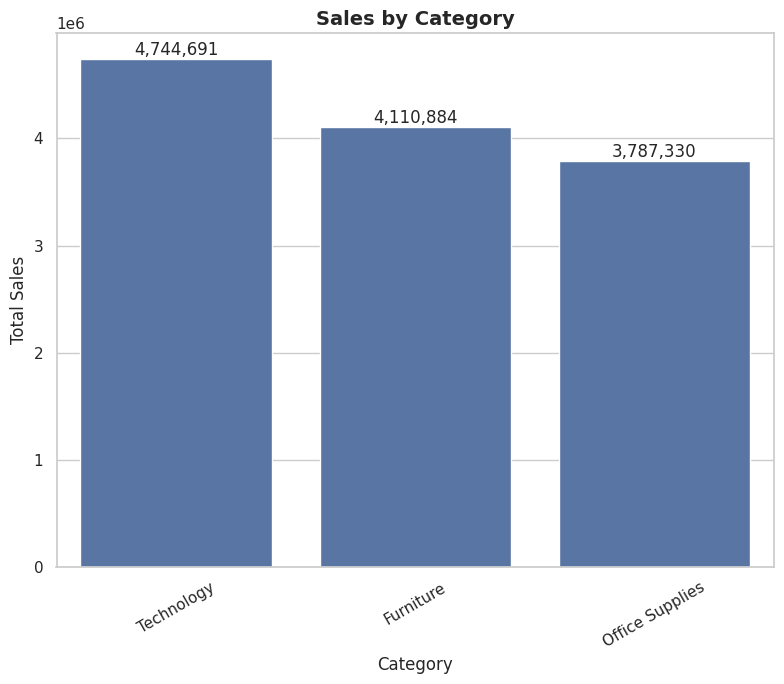

In [12]:
sns.set(style="whitegrid")

sales_by_category = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,7))
ax = sns.barplot(
    x=sales_by_category.index,
    y=sales_by_category.values
)

plt.title("Sales by Category", fontsize=14, weight='bold')
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.xticks(rotation=30)
for i, v in enumerate(sales_by_category.values):
    ax.text(i, v, f"{v:,.0f}", ha='center', va='bottom')

plt.tight_layout()
os.makedirs("images", exist_ok=True)
os.makedirs("images", exist_ok=True)
plt.savefig("images/sales_by_category.png", dpi=300)

plt.show()

### Insight

Technology is the highest-performing category in terms of sales, followed by Furniture and Office Supplies; showing technology products are the main revenue drivers for the business, indicating a strong demand in this category.

##Profit by Category

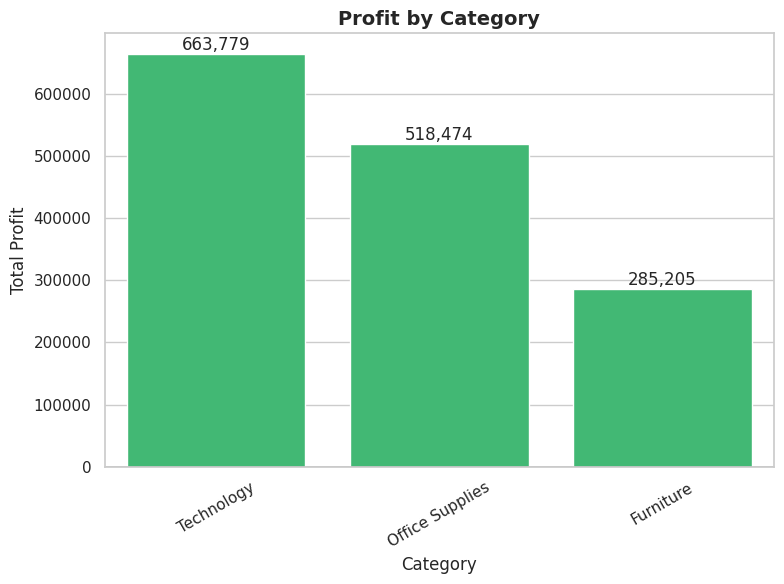

In [10]:
sns.set(style="whitegrid")
profit_by_category = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,6))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in profit_by_category.values]
ax = sns.barplot(
    x=profit_by_category.index,
    y=profit_by_category.values,
    hue=profit_by_category.index,
    palette=colors,
    legend=False
)

plt.title("Profit by Category", fontsize=14, weight='bold')
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.xticks(rotation=30)
plt.axhline(0, color='black', linewidth=1)
for i, v in enumerate(profit_by_category.values):
    ax.text(i, v, f"{v:,.0f}",
            ha='center',
            va='bottom' if v > 0 else 'top')

plt.tight_layout()
plt.savefig("images/profit_by_category.png", dpi=300)

plt.show()

### Insight

Technology is the most profitable category, which aligns with its position as the top-selling category.

However, Furniture generates high sales but relatively low profit compared to Office Supplies. This suggests that Furniture products may have higher costs, lower margins, or inefficiencies affecting profitability.

On the other hand, Office Supplies, despite having lower sales than Furniture, generates higher profit, indicating better profit margins.

##Profit Margin by Category

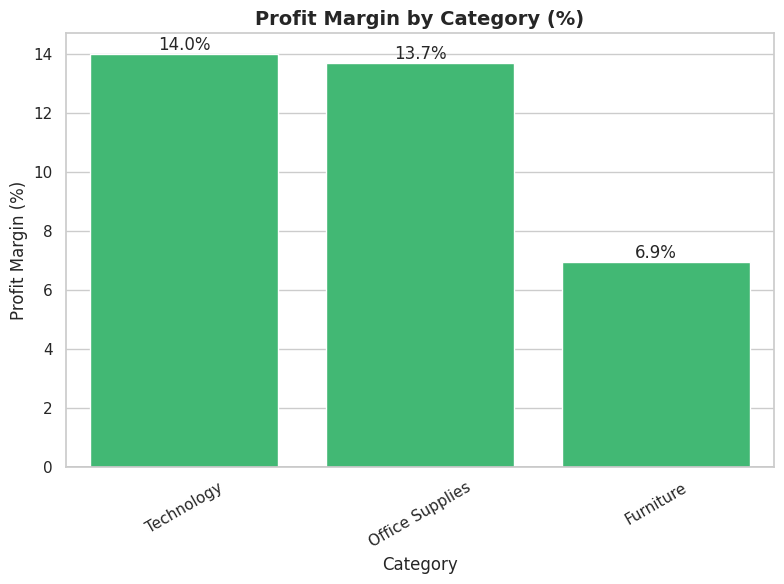

In [13]:
sns.set(style="whitegrid")

profit_margin_category = df.groupby("Category")[["Sales", "Profit"]].sum()
profit_margin_category["Profit Margin %"] = (
    profit_margin_category["Profit"] / profit_margin_category["Sales"]
) * 100

profit_margin_category = profit_margin_category.sort_values("Profit Margin %", ascending=False)

plt.figure(figsize=(8,6))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in profit_margin_category["Profit Margin %"]]
ax = sns.barplot(
    x=profit_margin_category.index,
    y=profit_margin_category["Profit Margin %"],
    hue=profit_margin_category.index,
    palette=colors,
    legend=False
)

plt.title("Profit Margin by Category (%)", fontsize=14, weight='bold')
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=30)
for i, v in enumerate(profit_margin_category["Profit Margin %"]):
    ax.text(i, v, f"{v:.1f}%",
            ha='center',
            va='bottom' if v > 0 else 'top')

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/profit_margin_category.png", dpi=300)

plt.show()

### Insight

Technology and Office Supplies show very similar and strong profit margins, both close to 14%, indicating efficient revenue generation.

In contrast, Furniture stands out for its significantly lower margin, at just under 7%, despite having high sales volume. This gap highlights a potential issue in cost structure or pricing, making Furniture the least efficient category in terms of profitability.

##Sales Over Time

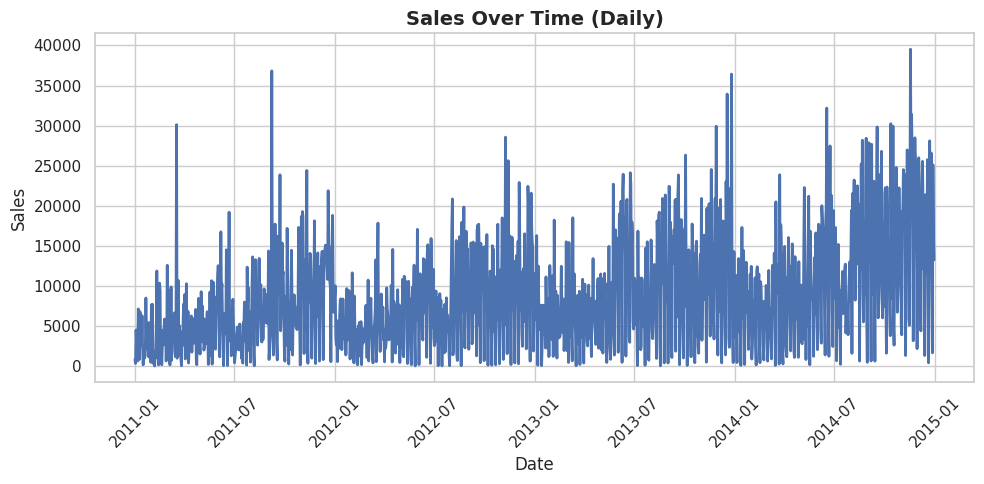

In [14]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])
sales_over_time = df.groupby("Order.Date")["Sales"].sum()

sns.set(style="whitegrid")
plt.figure(figsize=(10,5))
plt.plot(
    sales_over_time.index,
    sales_over_time.values,
    linewidth=2
)

plt.title("Sales Over Time (Daily)", fontsize=14, weight='bold')
plt.xlabel("Date")
plt.ylabel("Sales")

plt.xticks(rotation=45)
plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/sales_over_time_daily.png", dpi=300)

plt.show()

### Insight

Sales show an overall upward trend over time, indicating business growth despite short-term fluctuations. There are recurring spikes towards the end of each year, suggesting strong seasonal effects, likely driven by high-demand periods.

Daily sales are highly variable, which makes short-term patterns difficult to interpret without aggregation.

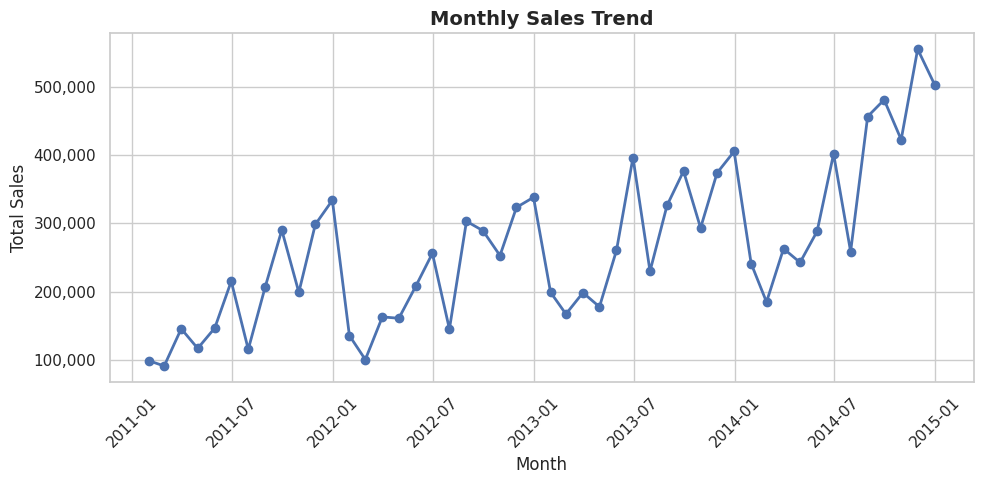

In [15]:
df["Order.Date"] = pd.to_datetime(df["Order.Date"])

sales_monthly = df.resample("ME", on="Order.Date")["Sales"].sum()
sns.set(style="whitegrid")
plt.figure(figsize=(10,5))

plt.plot(
    sales_monthly.index,
    sales_monthly.values,
    linewidth=2,
    marker='o'
)

plt.title("Monthly Sales Trend", fontsize=14, weight='bold')
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/monthly_sales.png", dpi=300)

plt.show()

### Insight

Monthly sales reveal a clear upward trend, indicating consistent business growth over time.

A recurring pattern emerges where sales peak towards the end of the year, reinforcing the presence of strong seasonal demand. In contrast, the beginning of each year consistently shows lower sales levels, suggesting a cyclical slowdown after high-demand periods.

Additionally, noticeable fluctuations throughout the year indicate variability in sales performance, with occasional mid-year increases.

##Top Products

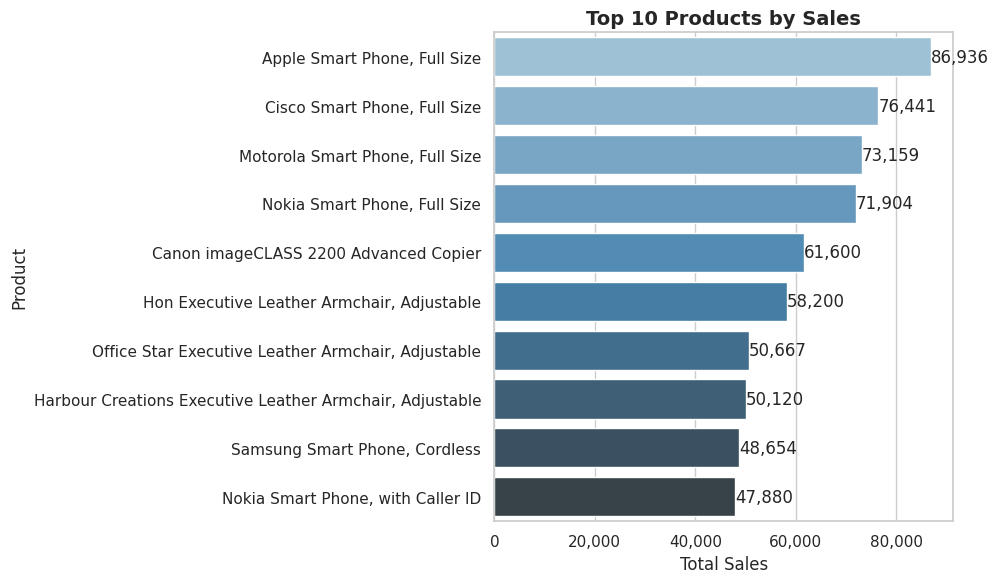

In [16]:
sns.set(style="whitegrid")

top_products_sales = (
    df.groupby("Product.Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
ax = sns.barplot(
    x=top_products_sales.values,
    y=top_products_sales.index,
    hue=top_products_sales.index,
    palette="Blues_d",
    legend=False
)

plt.title("Top 10 Products by Sales", fontsize=14, weight='bold')
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

for i, v in enumerate(top_products_sales.values):
    ax.text(v, i, f"{v:,.0f}", va='center')

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig("images/top_products.png", dpi=300)

plt.show()

### Insight

The top-selling products are led by smartphones, with Apple Smart Phone, Full Size standing out as the highest revenue generator.

Sales among the top 10 products are relatively well distributed, indicating that revenue is not concentrated in a single product but rather spread across multiple high-performing items.

The strong presence of technology-related products reinforces the earlier finding that the Technology category is the primary driver of revenue.

## Conclusion

This analysis explored sales performance across categories, time, and products using the Global Superstore dataset.

Overall, the business demonstrates consistent growth over time, with a clear upward trend in sales despite short-term fluctuations. Seasonal patterns are evident, with higher sales occurring towards the end of each year and lower performance at the beginning.

From a category perspective, Technology stands out as the main driver of both revenue and profit, while Office Supplies shows strong profitability relative to its sales. In contrast, Furniture, although generating high sales, presents significantly lower profit margins, highlighting potential inefficiencies.

At the product level, sales are distributed across multiple high-performing items, with technology products dominating the top positions. This reinforces the importance of the Technology category in overall business performance.

In summary, while the business is growing and generating solid revenue, there are clear opportunities to improve profitability, particularly by optimizing underperforming categories such as Furniture.